### Can institutional characteristics & performance indicators predict sustainability performance?



#### Import Libraries

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import matplotlib.pyplot as plt

#### Load Data

In [45]:
df = pd.read_csv("QS_DATASET.csv", encoding='latin-1')

print(df.shape)
df.head()

print(df.columns.tolist())
target = "Sustainability_Score"

(1503, 28)
['RANK_2025', 'RANK_2024', 'Institution_Name', 'Location', 'Region', 'SIZE', 'FOCUS', 'RES.', 'STATUS', 'Academic_Reputation_Score', 'Academic_Reputation_Rank', 'Employer_Reputation_Score', 'Employer_Reputation_Rank', 'Faculty_Student_Score', 'Faculty_Student_Rank', 'Citations_per_Faculty_Score', 'Citations_per_Faculty_Rank', 'International_Faculty_Score', 'International_Faculty_Rank', 'International_Students_Score', 'International_Students_Rank', 'International_Research_Network_Score', 'International_Research_Network_Rank', 'Employment_Outcomes_Score', 'Employment_Outcomes_Rank', 'Sustainability_Score', 'Sustainability_Rank', 'Overall_Score']


#### Select and Distinguish Features

In [46]:
features = [
    # Institutional characteristics

    "Region",
    "SIZE",
    "FOCUS",
    "RES.",
    "STATUS",

    # Performance indicators

    "Academic_Reputation_Score",
    "Employer_Reputation_Score",
    "Faculty_Student_Score",
    "Citations_per_Faculty_Score",
    "International_Faculty_Score",
    "International_Students_Score",
    "International_Research_Network_Score",
    "Employment_Outcomes_Score"
]
X = df[features]
y = df[target]


numeric_features = [

    "Academic_Reputation_Score",
    "Employer_Reputation_Score",
    "Faculty_Student_Score",
    "Citations_per_Faculty_Score",
    "International_Faculty_Score",
    "International_Students_Score",
    "International_Research_Network_Score",
    "Employment_Outcomes_Score"
]

categorical_features = [

    "Region",
    "SIZE",
    "FOCUS",
    "RES.",
    "STATUS"
]

#### Sanitisation and Pre-Processing

In [47]:
df["Sustainability_Score"] = pd.to_numeric(
    df["Sustainability_Score"],
    errors="coerce"
)

mask = df["Sustainability_Score"].notna()
X = X[mask]
y = df.loc[mask, "Sustainability_Score"]
print(y.isna().sum())

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

0


#### Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1187, 13)
(297, 13)


#### Random Forest Model

In [49]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf)
    ]
)

#### Train Model and Make Predictions

In [50]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### Evaluate Model

In [51]:
r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

print("R^2:", round(r2,3))
print("RMSE:", round(rmse,3))
print("MAE:", round(mae,3))

R^2: 0.757
RMSE: 15.499
MAE: 10.754


#### Cross-Validation

In [52]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)
print("Average CV R²:", cv_scores.mean())

[-0.59523514  0.26274647 -0.23000002 -0.13429735 -0.82217228]
Average CV R²: -0.3037916640796112


#### Hyperparameter Tuning

In [53]:
param_grid = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,None],
    "model__min_samples_split":[2,5]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)
print(grid.best_params_)

{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


#### Re-Evaluate on Tuned Parameters

In [54]:
best_model = grid.best_estimator_
best_predictions = best_model.predict(X_test)

r2 = r2_score(y_test,best_predictions)
rmse = np.sqrt(mean_squared_error(y_test,best_predictions))
mae = mean_absolute_error(y_test,best_predictions)

print("Final R^2:",round(r2,3))
print("Final RMSE:",round(rmse,3))
print("Final MAE:",round(mae,3))

Final R^2: 0.756
Final RMSE: 15.551
Final MAE: 10.71


#### Feature Importance

                                 Feature  Importance
0              Academic_Reputation_Score    0.511636
6   International_Research_Network_Score    0.146426
3            Citations_per_Faculty_Score    0.081522
4            International_Faculty_Score    0.067604
5           International_Students_Score    0.057054
1              Employer_Reputation_Score    0.038276
2                  Faculty_Student_Score    0.027993
7              Employment_Outcomes_Score    0.023585
13                        Region_Oceania    0.008316
14                                SIZE_L    0.007358
10                           Region_Asia    0.004781
20                              FOCUS_FO    0.003856
11                         Region_Europe    0.003650
15                                SIZE_M    0.003492
19                              FOCUS_FC    0.003305


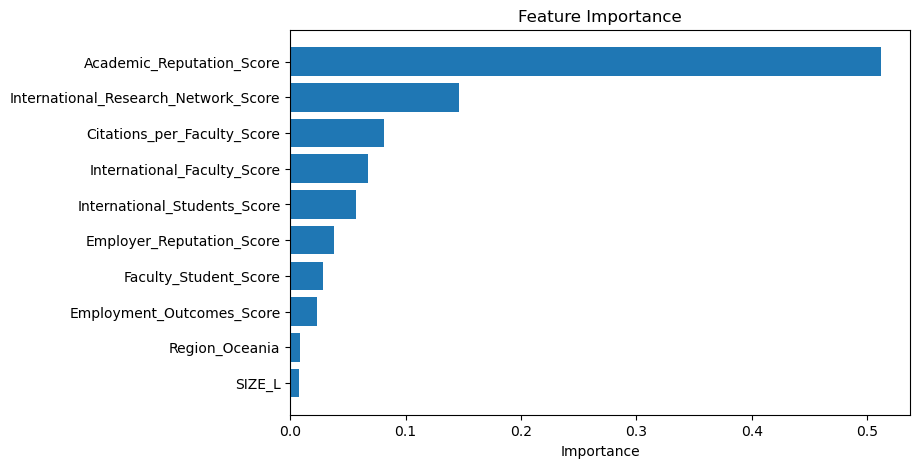

In [55]:
encoder = best_model.named_steps["preprocessor"]\
                    .named_transformers_["cat"]\
                    .named_steps["encoder"]

cat_names = encoder.get_feature_names_out(categorical_features)
feature_names = np.concatenate([
    numeric_features,
    cat_names
])

importances = best_model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))
top = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()